# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YoyuQre/flyrank_assgn_1/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
df= pd.read_csv('/content/content_refresh_anonymized.csv')

# Make a copy
data = df.copy()

# Binary target
y = (data["trend_direction"] == "down").astype(int)

# Remove identifiers and leakage columns
drop_cols = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct"
]

X = data.drop(columns=drop_cols)

# Separate numerical and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Handle missing values
X[num_cols] = X[num_cols].fillna(0)
X[cat_cols] = X[cat_cols].fillna("Unknown")

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)



Feature Matrix Shape: (30000, 66)
Target Shape: (30000,)


       impressions_90d    clicks_90d           ctr  avg_position  \
count     30000.000000  30000.000000  30000.000000   30000.00000   
mean       5200.366300     16.097333      0.510733      16.34238   
std       16838.019547     75.076958      3.279162      15.21679   
min           1.000000      0.000000      0.000000       0.00000   
25%          81.000000      0.000000      0.000000       6.20000   
50%         731.000000      1.000000      0.070000      10.80000   
75%        3615.250000      7.000000      0.290000      22.30000   
max      517715.000000   4178.000000    100.000000     245.00000   

       days_since_last_update  
count            30000.000000  
mean                46.098300  
std                 42.078709  
min                  1.000000  
25%                 20.000000  
50%                 20.000000  
75%                104.000000  
max                373.000000  


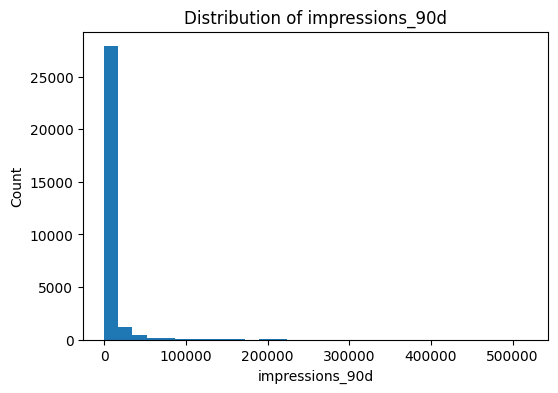

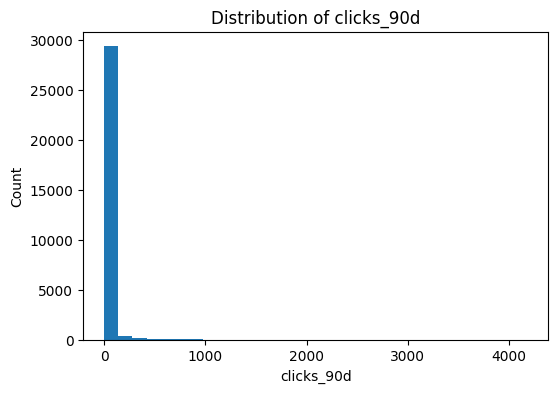

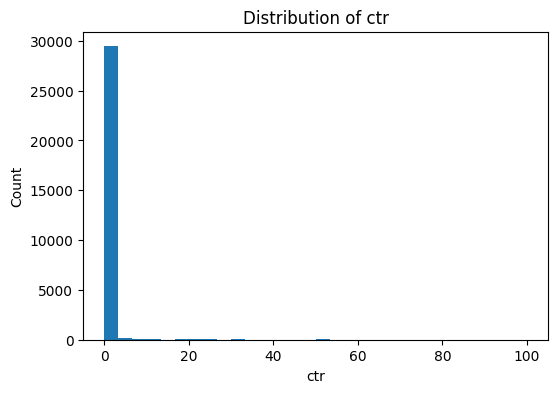

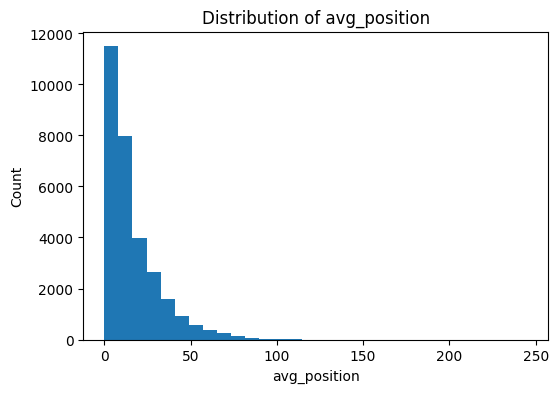

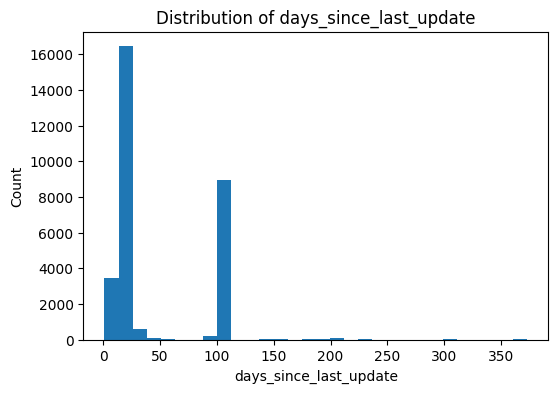

In [5]:
key_features = [
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "days_since_last_update"
]

# Summary statistics
print(df[key_features].describe())

# Histograms
for col in key_features:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

The distributions show that several key features are **highly right-skewed with heavy tails**. For example, `impressions_90d` has a median of **731** impressions but a mean of **5,200.4**, with values ranging up to **517,715**, indicating that a small number of pages receive exceptionally high traffic. Similarly, `clicks_90d` has a median of **1** click but a mean of **16.1**, with a maximum of **4,178** clicks. The `ctr` feature also contains a wide range of values (0 to 100), while `avg_position` varies from **0** to **245**, suggesting the presence of outliers. Finally, `days_since_last_update` ranges from **1** to **373** days, showing considerable variation in content freshness. These heavy-tailed distributions suggest that search-performance data is not normally distributed, and models should be robust to skewed values and outliers.


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal Test 1: `days_since_last_update`

**Verdict: CONFIRMED**

Pages with a downward trend have a higher average number of days since their last update (**49.25 days**) compared with pages that are not declining (**42.37 days**). This suggests that older content is more likely to experience declining search performance, although the effect is moderate.

### Signal Test 2: `ctr`

**Verdict: MIXED**

The average CTR is lower for declining pages (**0.32**) than for non-declining pages (**0.73**), which supports the expected relationship. However, the median CTR is slightly higher for declining pages (**0.08** vs. **0.04**), indicating that the distribution is highly skewed and influenced by outliers. CTR alone is therefore not a reliable indicator.

### Signal Test 3: `avg_position`

**Verdict: MIXED**

The average search position is slightly better for declining pages (**15.94**) than for non-declining pages (**16.82**), while the median position is slightly worse (**11.30** vs. **10.05**). These conflicting results suggest that average search position by itself is not a strong predictor of future decline and should be considered together with other features.


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Binary target
df["is_down"] = (df["trend_direction"] == "down").astype(int)

signals = [
    "days_since_last_update",
    "ctr",
    "avg_position"
]

for col in signals:
    print(f"\n{'='*60}")
    print(f"Signal: {col}")
    print(df.groupby("is_down")[col].describe()[["mean","50%","std"]])


Signal: days_since_last_update
              mean   50%        std
is_down                            
0        42.372543  20.0  40.857322
1        49.245788  20.0  42.832998

Signal: ctr
             mean   50%       std
is_down                          
0        0.731611  0.04  4.473514
1        0.324138  0.08  1.689773

Signal: avg_position
              mean    50%        std
is_down                             
0        16.823060  10.05  17.327709
1        15.936305  11.30  13.159382


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

I tested the assumption behind FlyRank's **content freshness** flag using the `days_since_last_update` feature. The results support the rule's assumption: pages with a downward trend have been updated less recently on average (**49.25 days**) than pages that are not declining (**42.37 days**). Although the difference is moderate, it indicates that older content is more likely to experience declining search performance. This suggests that content freshness is a useful signal for prioritizing pages, but it should be combined with other features rather than used as the only decision rule.


In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Test the freshness assumption used by the refresh flag

freshness_test = (
    df.groupby("is_down")["days_since_last_update"]
      .agg(["count", "mean", "median", "std"])
)

print(freshness_test)

         count       mean  median        std
is_down                                     
0        13738  42.372543    20.0  40.857322
1        16262  49.245788    20.0  42.832998


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The signal audit suggests that **content freshness is a useful indicator** when deciding which pages to review, as older pages are more likely to show declining search performance. However, no single metric consistently identifies declining pages, so content teams should avoid relying on one rule alone. Instead, pages should be prioritized using a combination of freshness, search performance, engagement, and ranking signals to make more informed content refresh decisions.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.